Retail Analysis Project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
'importing tools'

'importing tools'

In [2]:
df = pd.read_csv("sales_100k.csv")
df.head()

,Unnamed: 0,Sales_ID,Product_Category,Sales_Amount,Discount,Sales_Region,Date_of_Sale,Customer_Age,Customer_Gender,Sales_Representative
0,0,efc35a5f-e48c-4803-9f6d-ef32a60e1367,Movies,341.05,45.98,East Dianeport,2024-07-12,69.0,Male,Bruce Rodriguez
1,1,92a86e42-de42-4e0d-89f3-bbb0b7f354bd,Pet Supplies,594.71,29.59,North Linda,2024-05-07,32.0,Other,Patricia Pugh
2,2,1fbbdc48-f405-48f3-8274-750581552d26,Outdoor,351.90,49.78,Lake Josephmouth,2024-05-11,28.0,Other,Kevin Fuentes
3,3,1f329e7a-13f0-4518-9eeb-84815301d64c,Electronics,NaN,NaN,North Martinside,2024-09-02,NaN,NaN,Evelyn Price
4,4,6ef559dc-3e68-4009-9845-4bab54d897c6,Books,795.75,27.21,Michealshire,2024-05-02,21.0,Other,Joseph Chavez


Checking Columns

In [3]:
df.columns
df = df.drop(columns=["Sales_Representative"]) 
'Removing unnecessary column'

'Removing unnecessary column'

Inspection

In [4]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        100000 non-null  int64  
 1   Sales_ID          100000 non-null  str    
 2   Product_Category  100000 non-null  str    
 3   Sales_Amount      90000 non-null   float64
 4   Discount          90000 non-null   float64
 5   Sales_Region      100000 non-null  str    
 6   Date_of_Sale      100000 non-null  str    
 7   Customer_Age      90000 non-null   float64
 8   Customer_Gender   90000 non-null   str    
dtypes: float64(3), int64(1), str(5)
memory usage: 6.9 MB


np.int64(0)

In [5]:
df = df.dropna()
df = df.drop_duplicates()
'Removing missing values and duplicates'

'Removing missing values and duplicates'

In [6]:
df["Date_of_Sale"] = pd.to_datetime(df["Date_of_Sale"])
df["month"] = df["Date_of_Sale"].dt.month_name()
df["year"] = df["Date_of_Sale"].dt.year
df["day_of_week"] = df["Date_of_Sale"].dt.day_name()
df.head()

,Unnamed: 0,Sales_ID,Product_Category,Sales_Amount,Discount,Sales_Region,Date_of_Sale,Customer_Age,Customer_Gender,month,year,day_of_week
0,0,efc35a5f-e48c-4803-9f6d-ef32a60e1367,Movies,341.05,45.98,East Dianeport,2024-07-12,69.0,Male,July,2024,Friday
1,1,92a86e42-de42-4e0d-89f3-bbb0b7f354bd,Pet Supplies,594.71,29.59,North Linda,2024-05-07,32.0,Other,May,2024,Tuesday
2,2,1fbbdc48-f405-48f3-8274-750581552d26,Outdoor,351.90,49.78,Lake Josephmouth,2024-05-11,28.0,Other,May,2024,Saturday
4,4,6ef559dc-3e68-4009-9845-4bab54d897c6,Books,795.75,27.21,Michealshire,2024-05-02,21.0,Other,May,2024,Thursday
5,5,280065cd-ad2b-4c80-9fce-929da484ee06,Books,526.17,28.54,Joelmouth,2024-01-02,61.0,Female,January,2024,Tuesday


In [7]:
# Basic Analysis Questions

# 1. Total revenue
total_revenue = df["Sales_Amount"].sum()
print("Total Revenue:", total_revenue)

# 2. Average sale amount
average_sale = df["Sales_Amount"].mean()
print("Average Sale Amount:", average_sale)

# 3. Revenue by product category
revenue_by_category = df.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False)
print(revenue_by_category)

# 4. Revenue by sales region
revenue_by_region = df.groupby("Sales_Region")["Sales_Amount"].sum().sort_values(ascending=False)
print(revenue_by_region)

# 5. Revenue by customer gender
revenue_by_gender = df.groupby("Customer_Gender")["Sales_Amount"].sum()
print(revenue_by_gender)

# 6. Revenue by month
monthly_revenue = df.groupby("month")["Sales_Amount"].sum().sort_values(ascending=False)
print(monthly_revenue)

# 7. Revenue by day of week
day_revenue = df.groupby("day_of_week")["Sales_Amount"].sum().sort_values(ascending=False)
print(day_revenue)

# 8. Average discount by category
discount_by_category = df.groupby("Product_Category")["Discount"].mean().sort_values(ascending=False)
print(discount_by_category)

Total Revenue: 49515372.53
Average Sale Amount: 550.1708058888889
Product_Category
Movies             2127649.79
Toys               2107808.73
Books              2104440.86
Jewelry            2098907.32
Appliances         2096142.06
Personal Care      2091050.94
Groceries          2090515.92
Health             2087823.44
Music              2086191.80
Beauty             2081590.41
Sports             2078401.50
Furniture          2076003.13
Office Supplies    2064491.58
Clothing           2061267.99
Pet Supplies       2051885.55
Baby Products      2046518.86
Garden             2045201.33
Outdoor            2036937.30
DIY                2034444.29
Tools              2022642.75
Home & Kitchen     2022613.49
Electronics        2011872.37
Software           1997551.15
Automotive         1993419.97
Name: Sales_Amount, dtype: float64
Sales_Region
South Michael       45991.44
Lake Michael        43439.88
New Michael         41517.00
North John          40308.55
West Michael        38881.67
    

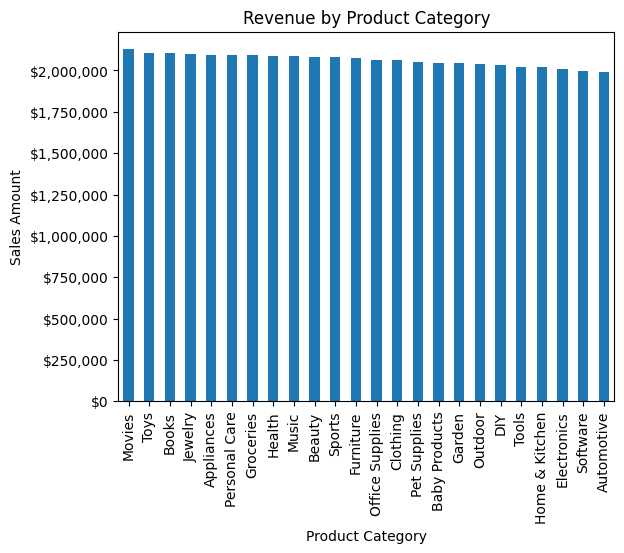

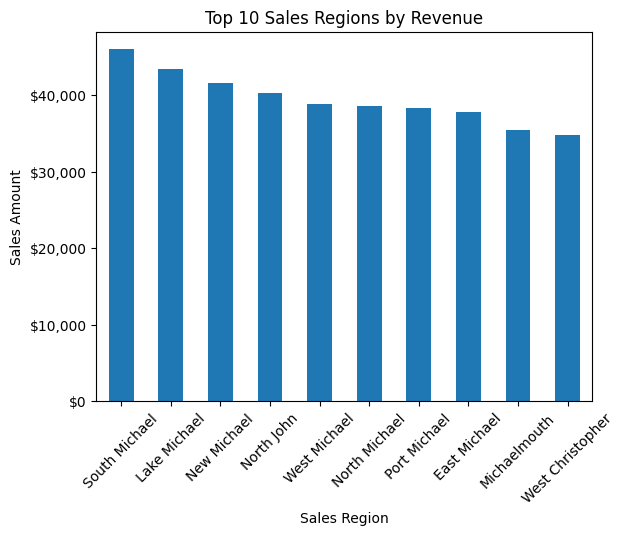

In [8]:
# Revenue by category chart
revenue_by_category.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales Amount")
from matplotlib.ticker import FuncFormatter

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'${x:,.0f}')
)
plt.show()

# Revenue by region chart
revenue_by_region = (
    df.groupby("Sales_Region")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_by_region.plot(kind="bar")

plt.title("Top 10 Sales Regions by Revenue")
plt.xlabel("Sales Region")
plt.ylabel("Sales Amount")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'${x:,.0f}')
)

plt.xticks(rotation=45)
plt.show()


Discount Charts

In [9]:
discounted_sales = df[df["Discount"] > 0]

discount_products = discounted_sales.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False)


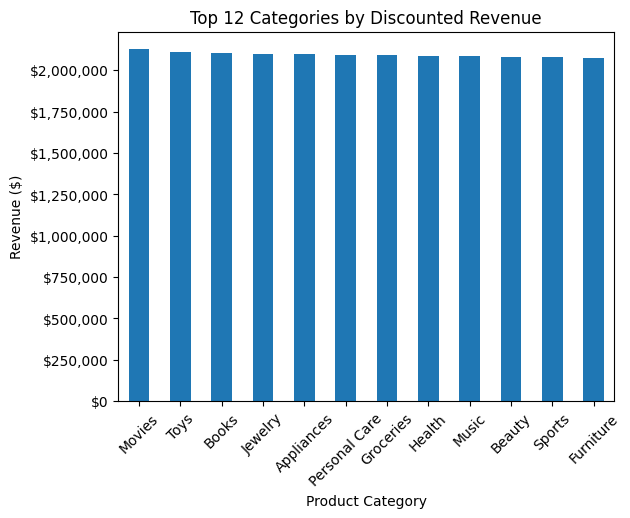

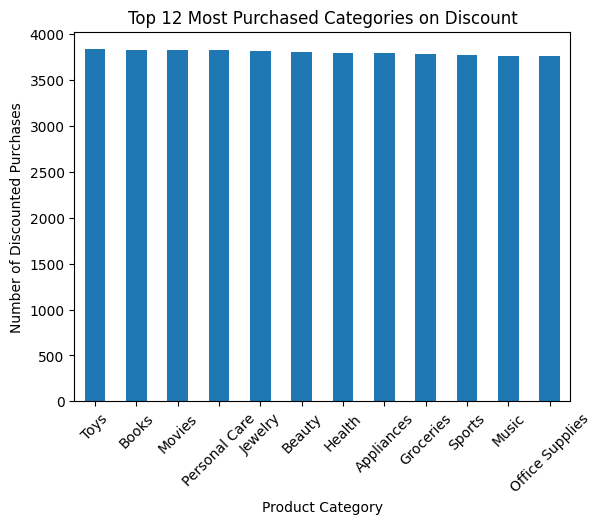

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

discount_products.plot(kind="bar")

discount_products = (
    discounted_sales.groupby("Product_Category")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
)

discount_products.plot(kind="bar")

plt.title("Top 12 Categories by Discounted Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'${x:,.0f}')
)

plt.xticks(rotation=45)
plt.show()

discount_count = (
    discounted_sales.groupby("Product_Category")
    .size()
    .sort_values(ascending=False)
    .head(12)
)

discount_count.plot(kind="bar")

plt.title("Top 12 Most Purchased Categories on Discount")
plt.xlabel("Product Category")
plt.ylabel("Number of Discounted Purchases")

plt.xticks(rotation=45)
plt.show()

In [11]:
# SQL ANALYSIS

import sqlite3

# Create/connect to SQLite database
conn = sqlite3.connect("retail_sales.db")

# Save dataframe as SQL table
df.to_sql("retail_sales", conn, if_exists="replace", index=False)

90000

In [12]:
query1 = """
SELECT
    Product_Category,
    SUM(Sales_Amount) AS total_revenue
FROM retail_sales
GROUP BY Product_Category
ORDER BY total_revenue DESC;
"""

sql_revenue_by_category = pd.read_sql(query1, conn)
sql_revenue_by_category
#Revenue by Category

,Product_Category,total_revenue
0,Movies,2127649.79
1,Toys,2107808.73
2,Books,2104440.86
3,Jewelry,2098907.32
4,Appliances,2096142.06
5,Personal Care,2091050.94
6,Groceries,2090515.92
7,Health,2087823.44
8,Music,2086191.80
9,Beauty,2081590.41


In [13]:
#Revenue by Region
query2 = """
SELECT
    Sales_Region,
    SUM(Sales_Amount) AS total_revenue
FROM retail_sales
GROUP BY Sales_Region
ORDER BY total_revenue DESC;
"""

sql_revenue_by_region = pd.read_sql(query2, conn)
sql_revenue_by_region

,Sales_Region,total_revenue
0,South Michael,45991.44
1,Lake Michael,43439.88
2,New Michael,41517.00
3,North John,40308.55
4,West Michael,38881.67
...,...,...
35883,West Oscarburgh,100.41
35884,Weissfort,100.34
35885,East Jaredport,100.34
35886,North Erikton,100.20


In [14]:
#Monthly Revenue
query4 = """
SELECT
    month,
    SUM(Sales_Amount) AS total_revenue
FROM retail_sales
GROUP BY month
ORDER BY total_revenue DESC;
"""

sql_monthly_revenue = pd.read_sql(query4, conn)
sql_monthly_revenue

,month,total_revenue
0,March,6178331.00
1,July,6094583.67
2,August,6045752.60
3,May,5999733.35
4,January,5933523.69
5,June,5904069.52
6,April,5854080.74
7,February,5546585.39
8,September,1958712.57


In [15]:
#Average Discount by Category
query5 = """
SELECT
    Product_Category,
    AVG(Discount) AS avg_discount
FROM retail_sales
GROUP BY Product_Category
ORDER BY avg_discount DESC;
"""

sql_discount_by_category = pd.read_sql(query5, conn)
sql_discount_by_category

,Product_Category,avg_discount
0,Tools,25.235738
1,Electronics,25.182140
2,Groceries,25.178250
3,Beauty,25.141716
4,Toys,25.131573
5,Baby Products,25.104703
6,Movies,25.067106
7,DIY,25.056078
8,Furniture,24.966970
9,Music,24.945746


In [17]:
#Export for Power BI
# Export cleaned dataset
df.to_csv("cleaned_retail_sales_data.csv", index=False)

# Export SQL summary tables
sql_revenue_by_category.to_csv("sql_revenue_by_category.csv", index=False)
sql_revenue_by_region.to_csv("sql_revenue_by_region.csv", index=False)
sql_monthly_revenue.to_csv("sql_monthly_revenue.csv", index=False)
sql_discount_by_category.to_csv("sql_discount_by_category.csv", index=False)

# Close SQL connection
conn.close()

print("Cleaned data and SQL files exported successfully.")

Cleaned data and SQL files exported successfully.
